In [1]:
# parametres a changer
variante = "nb"                   # "rgb", "nb", "contours"
normalisation = "normalisee"      # "normalisee" ou "non_normalisee"
gamma = 0.01                      # largeur des gaussiennes : phi = e^(-gamma * distance^2)
nb_centres = 100                  # K du kmeans (moins de centres = modele plus simple)
seed = 42                         # graine pour le kmeans (init aleatoire des centres)

#  sur rgb (d=49152) c'est ~10x plus lent que nb, prevoir 1-2 min par run

In [2]:
# compile rbf.cpp puis lance le binaire
import subprocess
from pathlib import Path

# on remonte jusqu'a la racine du projet (le dossier qui contient preprocessing)
racine = Path.cwd()
while racine != racine.parent and not (racine / "preprocessing").exists():
    racine = racine.parent

dossier_rbf = racine / "models" / "rbf"
chemin_cpp = dossier_rbf / "rbf.cpp"
chemin_exec = dossier_rbf / "rbf"

# -I dossier_rbf pour trouver eigen-5.0.0, -O2 sinon c'est trop lent
subprocess.check_call(["g++", "-O2", "-std=c++17", str(chemin_cpp), "-o", str(chemin_exec), "-I", str(dossier_rbf)], cwd=str(racine))

def lancer_rbf(variante, normalisation, gamma, nb_centres, seed):
    base = racine / "datasets" / "transformed" / variante / normalisation
    cmd = [
        str(chemin_exec),
        str(base / "X_train.f32bin"), str(base / "y_train.i32bin"),
        str(base / "X_test.f32bin"), str(base / "y_test.i32bin"),
        str(gamma), str(nb_centres), str(seed),
    ]
    return subprocess.check_output(cmd, text=True, cwd=str(racine))

sortie = lancer_rbf(variante, normalisation, gamma, nb_centres, seed)
# on n'affiche pas les lignes "kmeans iteration" (juste du bruit)
for ligne in sortie.splitlines():
    if not ligne.startswith("kmeans iteration"):
        print(ligne)

Chargé train: n=1200, d=16384
Chargé test : n=301, d=16384
Entraînement RBF kmeans, gamma=0.01, nb_centres=100, seed=42
acc train 0.576
acc test 0.545
confusion
67 16 15
28 51 27
31 20 46


In [3]:
def parser_sortie(sortie):
    acc_train = None
    acc_test = None
    confusion = None
    lignes = sortie.strip().splitlines()
    for i, ligne in enumerate(lignes):
        if ligne.startswith("acc train"):
            acc_train = float(ligne.split()[2])
        if ligne.startswith("acc test"):
            acc_test = float(ligne.split()[2])
        if ligne.strip() == "confusion":
            confusion = [[int(x) for x in lignes[i + 1 + j].split()] for j in range(3)]
    return acc_train, acc_test, confusion

acc_train, acc_test, confusion = parser_sortie(sortie)
print("acc train:", acc_train)
print("acc test :", acc_test)
print("confusion:", confusion)

acc train: 0.576
acc test : 0.545
confusion: [[67, 16, 15], [28, 51, 27], [31, 20, 46]]


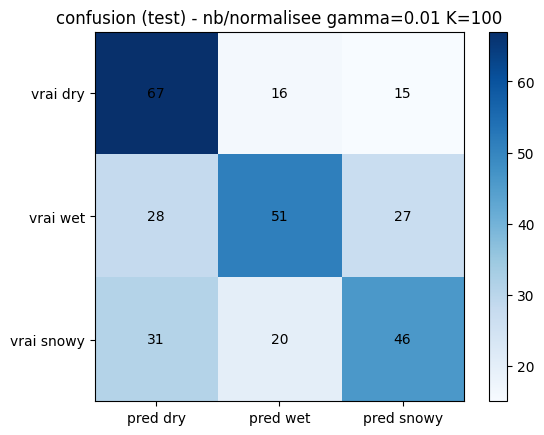

In [4]:
# matrice confusion test
import matplotlib.pyplot as plt

plt.imshow(confusion, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1, 2], ["pred dry", "pred wet", "pred snowy"])
plt.yticks([0, 1, 2], ["vrai dry", "vrai wet", "vrai snowy"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, confusion[i][j], ha="center", va="center")
plt.title(f"confusion (test) - {variante}/{normalisation} gamma={gamma} K={nb_centres}")
plt.show()

gamma=0.0001 : train 0.618 test 0.542
gamma=0.001 : train 0.637 test 0.601
gamma=0.01 : train 0.576 test 0.545
gamma=0.1 : train 0.482 test 0.422
gamma=1.0 : train 0.403 test 0.385


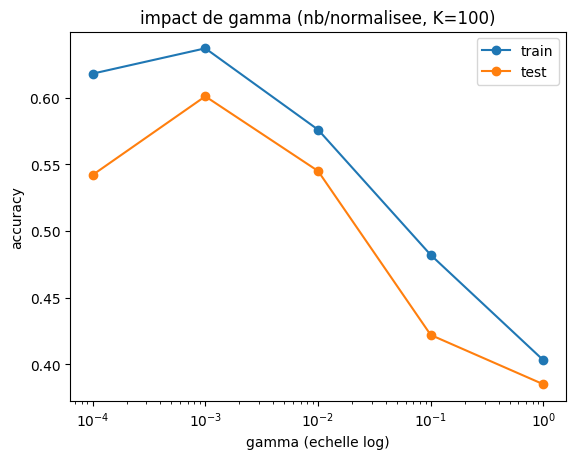

In [8]:
# impact de gamma 
# trop petit = sous apprentissage, trop grand = par coeur
gammas_a_tester = [0.0001, 0.001, 0.01, 0.1, 1.0]

accs_train = []
accs_test = []
for g in gammas_a_tester:
    s = lancer_rbf(variante, normalisation, g, nb_centres, seed)
    a_train, a_test, _ = parser_sortie(s)
    accs_train.append(a_train)
    accs_test.append(a_test)
    print(f"gamma={g} : train {a_train} test {a_test}")

plt.plot(gammas_a_tester, accs_train, marker="o", label="train")
plt.plot(gammas_a_tester, accs_test, marker="o", label="test")
plt.xscale("log")
plt.xlabel("gamma (echelle log)")
plt.ylabel("accuracy")
plt.title(f"impact de gamma ({variante}/{normalisation}, K={nb_centres})")
plt.legend()
plt.show()

nb_centres=10 : train 0.433 test 0.462
nb_centres=30 : train 0.507 test 0.512
nb_centres=60 : train 0.546 test 0.568
nb_centres=100 : train 0.576 test 0.545
nb_centres=200 : train 0.619 test 0.551


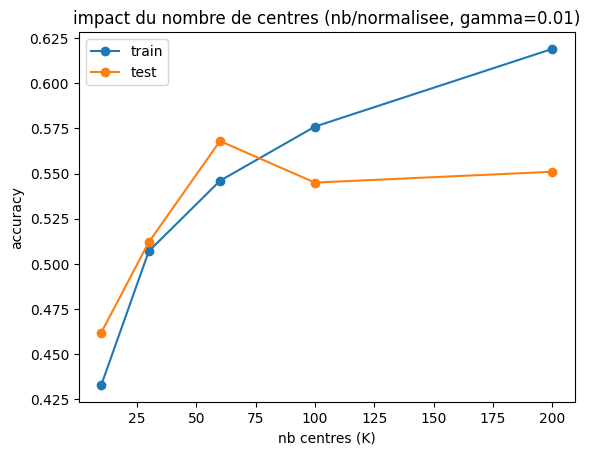

In [6]:
# impact nb centres ( donc complexite du modele askip)
centres_a_tester = [10, 30, 60, 100, 200]

accs_train = []
accs_test = []
for k in centres_a_tester:
    s = lancer_rbf(variante, normalisation, gamma, k, seed)
    a_train, a_test, _ = parser_sortie(s)
    accs_train.append(a_train)
    accs_test.append(a_test)
    print(f"nb_centres={k} : train {a_train} test {a_test}")

plt.plot(centres_a_tester, accs_train, marker="o", label="train")
plt.plot(centres_a_tester, accs_test, marker="o", label="test")
plt.xlabel("nb centres (K)")
plt.ylabel("accuracy")
plt.title(f"impact du nombre de centres ({variante}/{normalisation}, gamma={gamma})")
plt.legend()
plt.show()

rgb/normalisee : acc test 0.495
rgb/non_normalisee : acc test 0.326
nb/normalisee : acc test 0.545
nb/non_normalisee : acc test 0.326
contours/normalisee : acc test 0.528
contours/non_normalisee : acc test 0.326


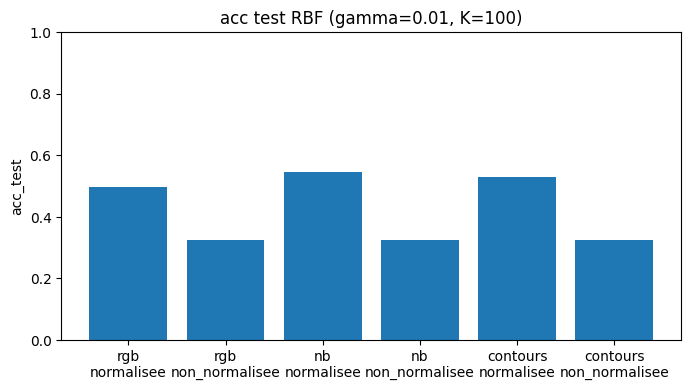

In [7]:
# meme modele sur les 6 variantes, on compare l'acc test

labels = []
valeurs = []
for v in ["rgb", "nb", "contours"]:
    for norm in ["normalisee", "non_normalisee"]:
        s = lancer_rbf(v, norm, gamma, nb_centres, seed)
        _, a_test, _ = parser_sortie(s)
        labels.append(f"{v}\n{norm}")
        valeurs.append(a_test)
        print(f"{v}/{norm} : acc test {a_test}")

plt.figure(figsize=(8, 4))
plt.bar(labels, valeurs)
plt.ylabel("acc_test")
plt.title(f"acc test RBF (gamma={gamma}, K={nb_centres})")
plt.ylim(0, 1)
plt.show()